In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('../Dataset/ecommerce_cleaned.csv', dtype={'increment_id': str})
df['created_at'] = pd.to_datetime(df['created_at'])
print("Đọc dữ liệu thành công, số dòng:", len(df))

Đọc dữ liệu thành công, số dòng: 582199


In [38]:
#  2.Nạp thư viện, Cấu hình và Làm sạch dữ liệu
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

SUCCESS = {"complete", "received"}
REFUND = {"refund", "order_refunded"}
BLUE, RED, GREY, ORANGE = "#2F6DB5", "#C8423B", "#8A94A6", "#E8A33D"
OUT = "eda_output"
os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 10, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25,
    "axes.axisbelow": True, "figure.dpi": 150, "savefig.bbox": "tight",
})

def pct_fmt(x, _): return f"{x:.0f}%"
def vn(x, d=0): return f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")

S = {} # Dictionary lưu stats

# Ép kiểu dữ liệu
for c in ["price", "qty_ordered", "grand_total", "discount_amount"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", "").str.strip(), errors="coerce")

df["status"] = df["status"].astype(str).str.strip().str.lower().replace({"nan": "unknown"})
df["category_name_1"] = df["category_name_1"].fillna("Unknown")

# Lọc các dòng hợp lệ
df = df.dropna(subset=["item_id", "increment_id", "sku", "Customer ID"])
df = df[(df.price > 0) & (df.grand_total >= 0) & (df.discount_amount >= 0)].copy()

# Xử lý thời gian và doanh thu
df["created_at"] = pd.to_datetime(df["created_at"])
df["line_gross_value"] = df.price * df.qty_ordered
df["line_net_value"] = df.line_gross_value - df.discount_amount

# Nhóm trạng thái
df["is_success"] = df.status.isin(SUCCESS)
df["status_group"] = np.where(df.is_success, "Thành công",
                      np.where(df.status == "canceled", "Hủy",
                      np.where(df.status.isin(REFUND), "Hoàn tiền", "Khác")))

# TẠO BIẾN succ CHO CÁC CELL SAU
succ = df[df.is_success].copy()

print(f"✅ Hoàn tất! Số dòng hợp lệ dùng để phân tích: {len(df):,}")

✅ Hoàn tất! Số dòng hợp lệ dùng để phân tích: 582,199


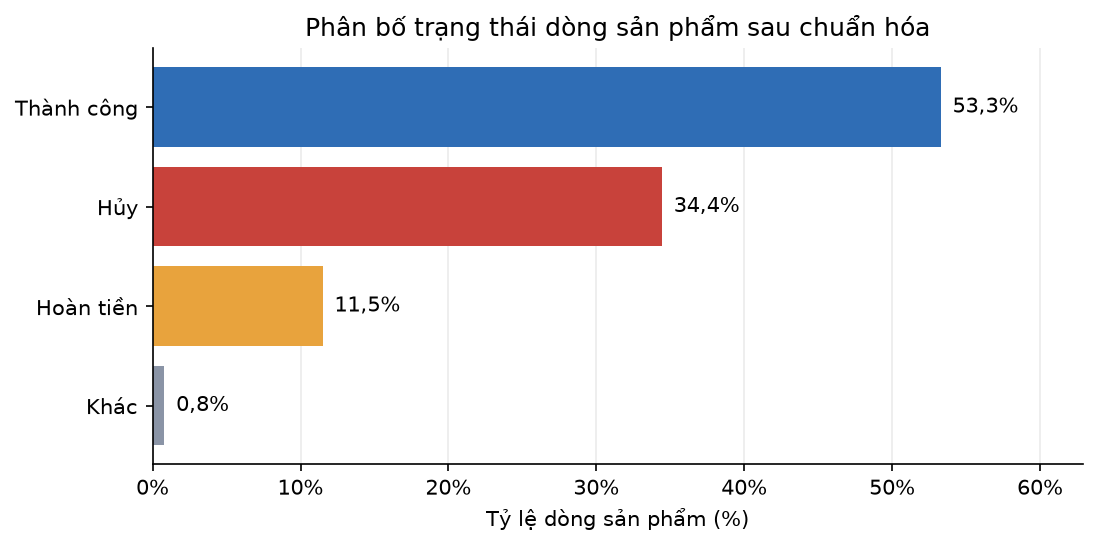

In [39]:
# 2.5.1 - Phân bố trạng thái
# Đếm theo cấp độ DÒNG SẢN PHẨM (Line Item)
grp_line = df.status_group.value_counts(normalize=True).reindex(
    ["Thành công", "Hủy", "Hoàn tiền", "Khác"]
).fillna(0) * 100

fig, ax = plt.subplots(figsize=(8, 3.6))
cols = [BLUE, RED, ORANGE, GREY]
ax.barh(grp_line.index[::-1], grp_line.values[::-1], color=cols[::-1])

for i, v in enumerate(grp_line.values[::-1]):
    if v > 0: 
        ax.text(v + 0.8, i, f"{v:.1f}%".replace(".", ","), va="center")

ax.set_xlim(0, grp_line.max() * 1.18)
ax.xaxis.set_major_formatter(FuncFormatter(pct_fmt))
ax.set_xlabel("Tỷ lệ dòng sản phẩm (%)")
ax.set_title("Phân bố trạng thái dòng sản phẩm sau chuẩn hóa") 
ax.grid(axis="y", visible=False)

fig.savefig(f"{OUT}/eda1_status.png")
plt.show()

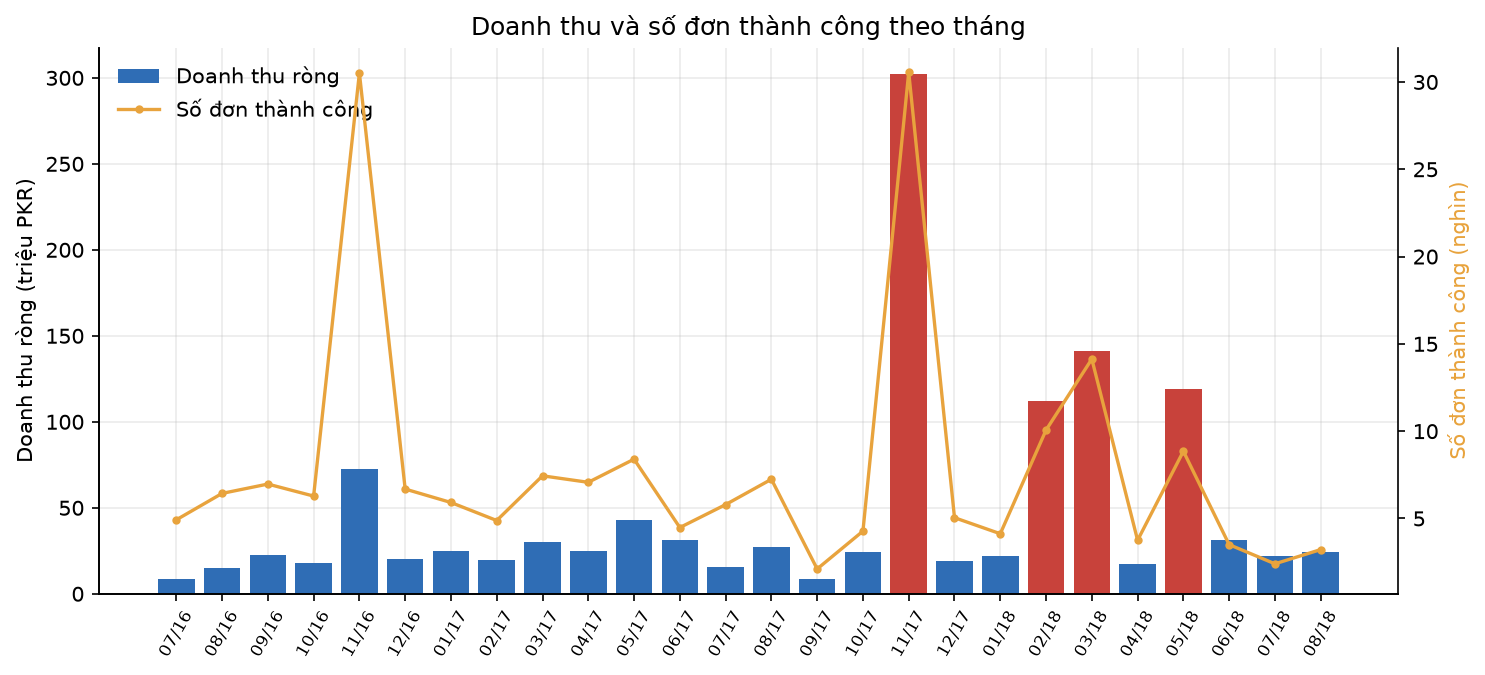

In [42]:
# 2.5.2 - Xu hướng doanh thu theo tháng

succ = succ.assign(month=succ.created_at.dt.to_period("M"))

mon = succ.groupby("month").agg(
    revenue=("line_net_value", "sum"),
    orders=("increment_id", "nunique")
)

mon["revenue_m"] = mon.revenue / 1e6
med = mon.revenue_m.median()

fig, ax = plt.subplots(figsize=(10, 4.6))

x = np.arange(len(mon))

# Cột doanh thu
colors = [RED if v > 3 * med else BLUE for v in mon.revenue_m]

bars = ax.bar(
    x,
    mon.revenue_m,
    color=colors,
    label="Doanh thu ròng"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{p.month:02d}/{str(p.year)[2:]}" for p in mon.index],
    rotation=60,
    fontsize=8
)

ax.set_ylabel("Doanh thu ròng (triệu PKR)")
ax.set_title("Doanh thu và số đơn thành công theo tháng")

# Đường số đơn
ax2 = ax.twinx()

line, = ax2.plot(
    x,
    mon.orders / 1000,
    color=ORANGE,
    marker="o",
    ms=3,
    lw=1.6,
    label="Số đơn thành công"
)

ax2.set_ylabel(
    "Số đơn thành công (nghìn)",
    color=ORANGE
)

ax2.grid(False)
ax2.spines["right"].set_visible(True)

# ===== LEGEND =====
ax.legend(
    handles=[bars, line],
    labels=["Doanh thu ròng", "Số đơn thành công"],
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.savefig(f"{OUT}/eda2_monthly.png", dpi=300, bbox_inches="tight")
plt.show()

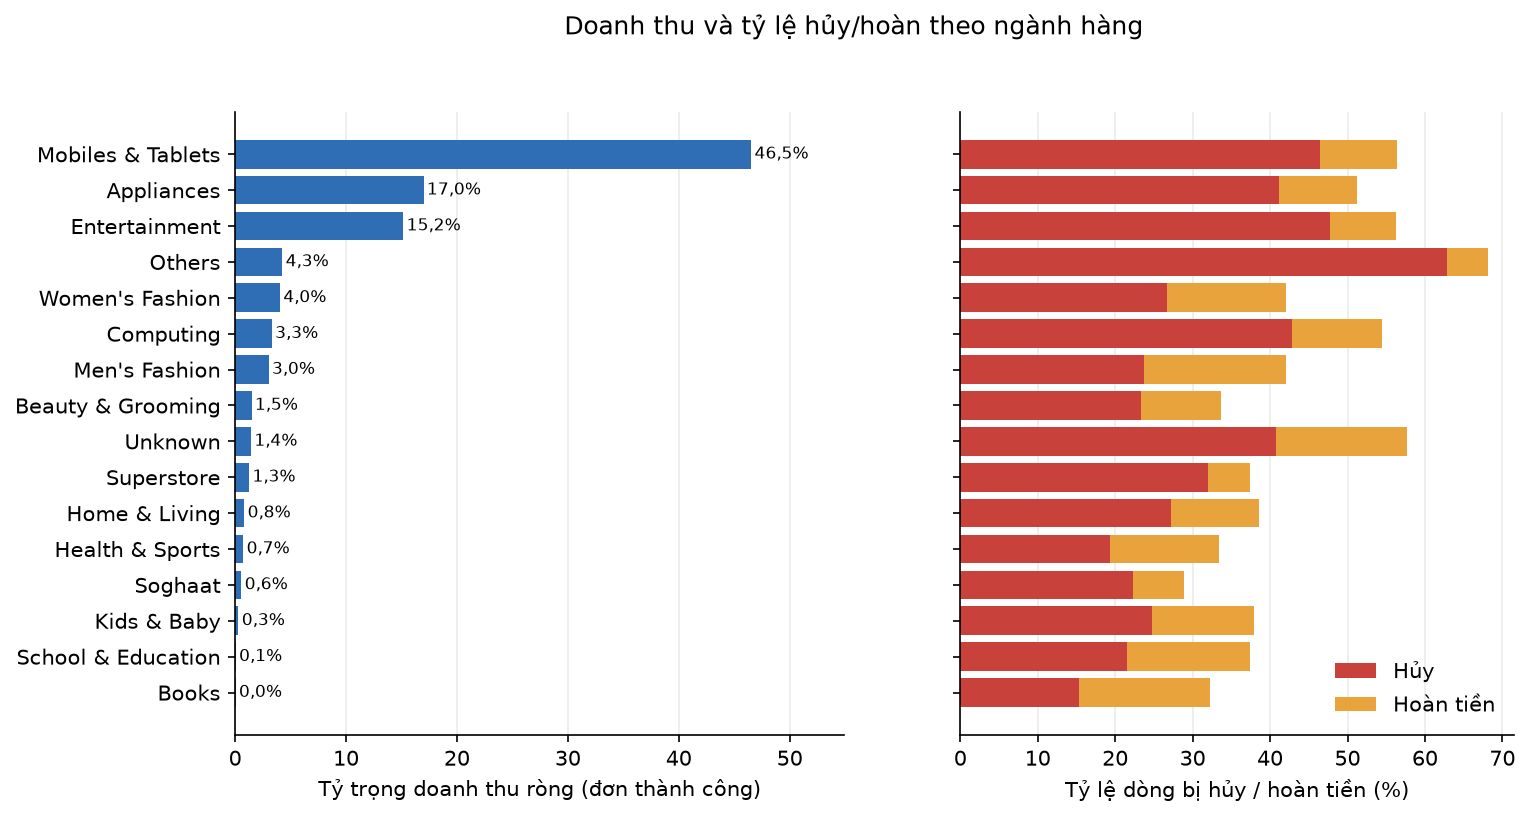

In [41]:
#2.5.3 - Ngành hàng
cat = df.groupby("category_name_1").agg(
        cancel=("status_group", lambda s: (s == "Hủy").mean() * 100),
        refund=("status_group", lambda s: (s == "Hoàn tiền").mean() * 100))
rev_cat = succ.groupby("category_name_1").line_net_value.sum() / 1e6
cat["revenue_m"] = rev_cat
cat = cat.fillna(0).sort_values("revenue_m", ascending=True)
cat["rev_share"] = cat.revenue_m / cat.revenue_m.sum() * 100

fig, axs = plt.subplots(1, 2, figsize=(11, 5.4), sharey=True, gridspec_kw={"width_ratios": [1.1, 1]})
axs[0].barh(cat.index, cat.rev_share, color=BLUE)
for i, v in enumerate(cat.rev_share): 
    axs[0].text(v + 0.3, i, f"{v:.1f}%".replace(".", ","), va="center", fontsize=8)
axs[0].set_xlabel("Tỷ trọng doanh thu ròng (đơn thành công)")
axs[0].set_xlim(0, cat.rev_share.max() * 1.18)
axs[0].grid(axis="y", visible=False)

axs[1].barh(cat.index, cat.cancel, color=RED, label="Hủy")
axs[1].barh(cat.index, cat.refund, left=cat.cancel, color=ORANGE, label="Hoàn tiền")
axs[1].set_xlabel("Tỷ lệ dòng bị hủy / hoàn tiền (%)")
axs[1].legend(loc="lower right", frameon=False)
axs[1].grid(axis="y", visible=False)

fig.suptitle("Doanh thu và tỷ lệ hủy/hoàn theo ngành hàng", y=1.0)
fig.savefig(f"{OUT}/eda3_category.png")
plt.show()

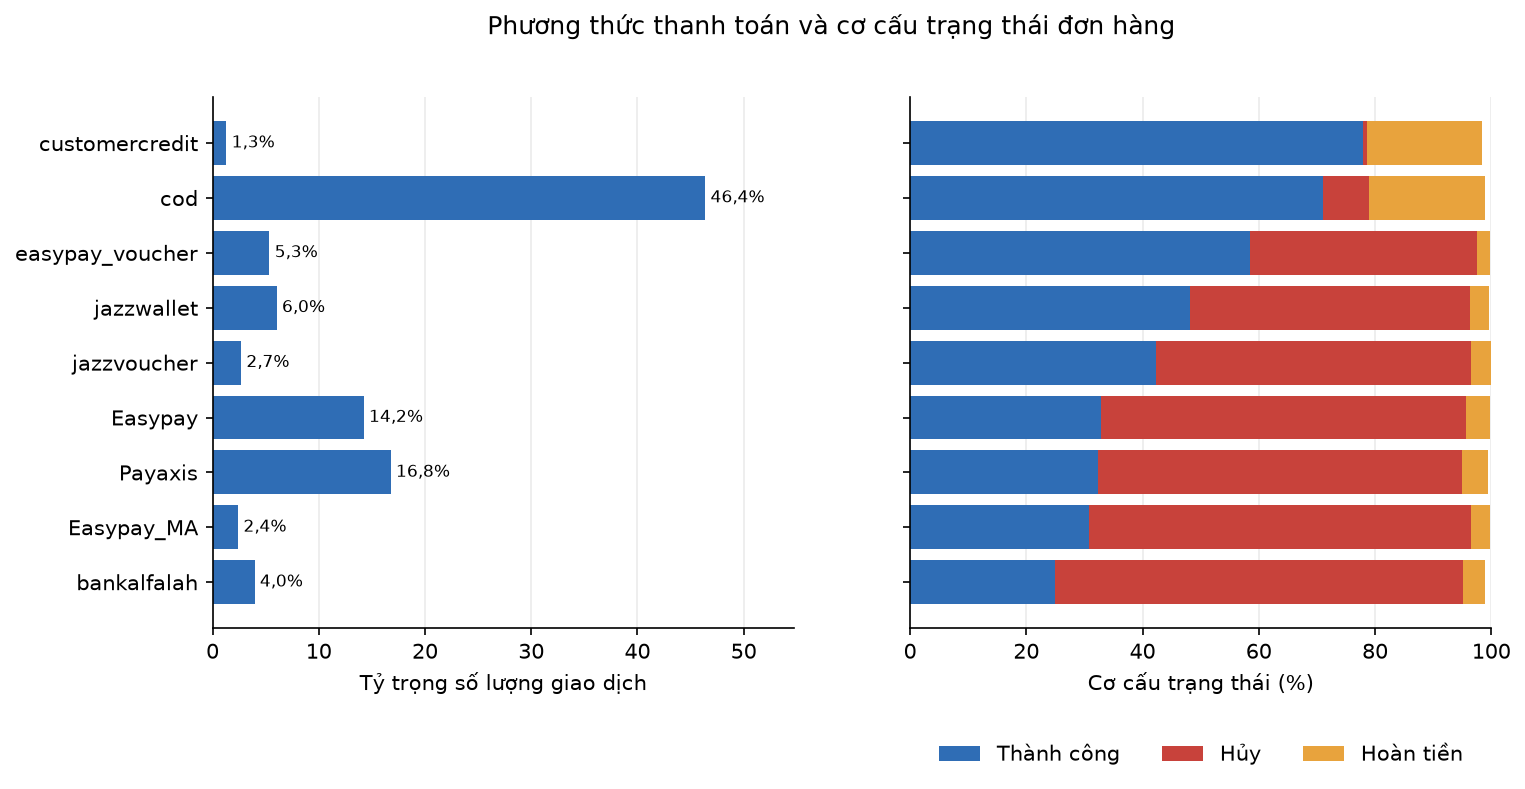

In [35]:
# 2.5.4 - Phương thức thanh toán
pay = df.groupby("payment_method").agg(
        lines=("item_id", "count"),
        cancel=("status_group", lambda s: (s == "Hủy").mean() * 100),
        refund=("status_group", lambda s: (s == "Hoàn tiền").mean() * 100),
        success=("status_group", lambda s: (s == "Thành công").mean() * 100))
pay["share"] = pay.lines / pay.lines.sum() * 100
big = pay[pay.lines >= 2000].sort_values("success")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
axs[0].barh(big.index, big.share, color=BLUE)
for i, v in enumerate(big.share): 
    axs[0].text(v + 0.5, i, f"{v:.1f}%".replace(".", ","), va="center", fontsize=8)
axs[0].set_xlabel("Tỷ trọng số lượng giao dịch")
axs[0].set_xlim(0, big.share.max() * 1.18)
axs[0].grid(axis="y", visible=False)

axs[1].barh(big.index, big.success, color=BLUE, label="Thành công")
axs[1].barh(big.index, big.cancel, left=big.success, color=RED, label="Hủy")
axs[1].barh(big.index, big.refund, left=big.success + big.cancel, color=ORANGE, label="Hoàn tiền")
axs[1].set_xlim(0, 100)
axs[1].set_xlabel("Cơ cấu trạng thái (%)")
axs[1].grid(axis="y", visible=False)
axs[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)

fig.suptitle("Phương thức thanh toán và cơ cấu trạng thái đơn hàng", y=1.0)
fig.savefig(f"{OUT}/eda4_payment.png")
plt.show()

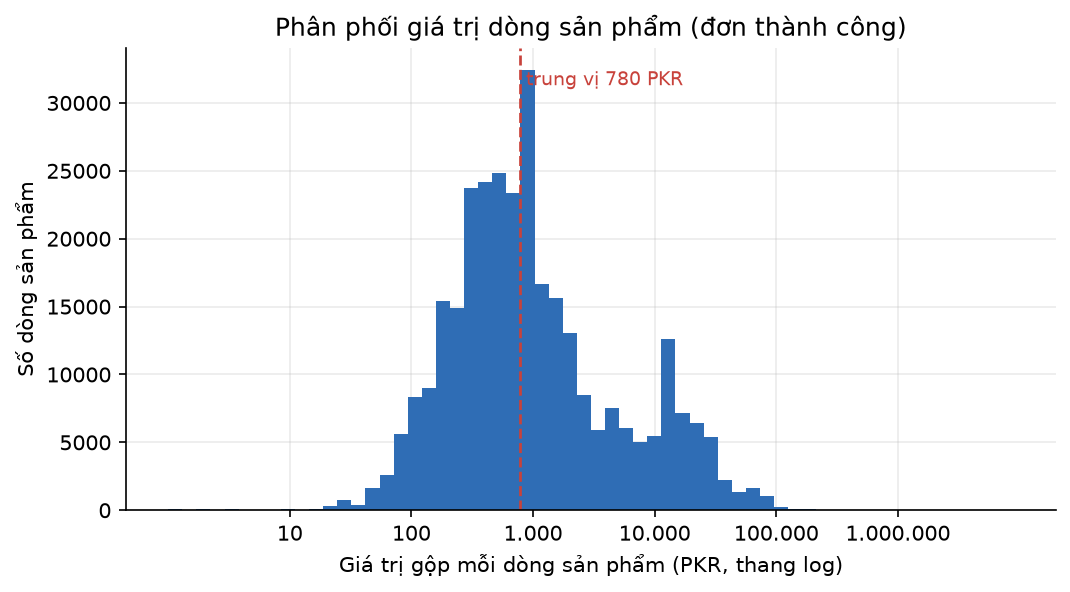

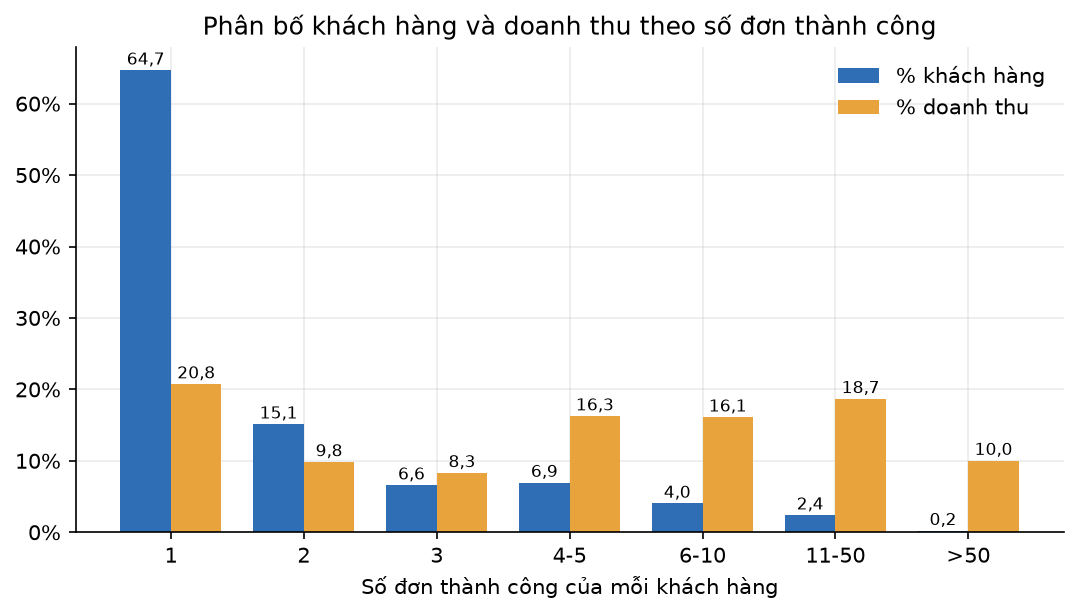

In [36]:
# 2.5.5 - Phân bố Khách hàng & Giá trị giao dịch
# 1. Phân phối giá trị giao dịch (Thang Log)
q = succ.line_gross_value.quantile([.25, .5, .75, .9, .99])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log10(succ.line_gross_value.clip(lower=1)), bins=60, color=BLUE)
ticks = [1, 2, 3, 4, 5, 6]
ax.set_xticks(ticks)
ax.set_xticklabels([vn(10 ** t) for t in ticks])
ax.axvline(np.log10(q[.5]), color=RED, ls="--", lw=1.3)
ax.text(np.log10(q[.5]) + 0.05, ax.get_ylim()[1] * 0.92, f"trung vị {vn(q[.5])} PKR", color=RED, fontsize=9)
ax.set_xlabel("Giá trị gộp mỗi dòng sản phẩm (PKR, thang log)")
ax.set_ylabel("Số dòng sản phẩm")
ax.set_title("Phân phối giá trị dòng sản phẩm (đơn thành công)")
fig.savefig(f"{OUT}/eda5_price.png")
plt.show()

# 2. Phân bố Khách hàng theo số đơn
orders = succ.groupby(["Customer ID", "increment_id"]).agg(
    date=("created_at", "min"), rev=("line_net_value", "sum")).reset_index()

cust = orders.groupby("Customer ID").agg(n=("increment_id", "nunique"), rev=("rev", "sum"))

bins = [0, 1, 2, 3, 5, 10, 50, 10 ** 6]
labels = ["1", "2", "3", "4-5", "6-10", "11-50", ">50"]
cust["bucket"] = pd.cut(cust.n, bins=bins, labels=labels)
b = cust.groupby("bucket", observed=False).agg(cust=("n", "size"), rev=("rev", "sum"))
b["cust_pct"] = b.cust / b.cust.sum() * 100
b["rev_pct"] = b.rev / b.rev.sum() * 100

fig2, ax2 = plt.subplots(figsize=(8.5, 4.2))
w = 0.38
xi = np.arange(len(b))
ax2.bar(xi - w / 2, b.cust_pct, w, color=BLUE, label="% khách hàng")
ax2.bar(xi + w / 2, b.rev_pct, w, color=ORANGE, label="% doanh thu")

for i, (a, c) in enumerate(zip(b.cust_pct, b.rev_pct)):
    ax2.text(i - w / 2, a + 0.8, f"{a:.1f}".replace(".", ","), ha="center", fontsize=8)
    ax2.text(i + w / 2, c + 0.8, f"{c:.1f}".replace(".", ","), ha="center", fontsize=8)

ax2.set_xticks(xi); ax2.set_xticklabels(b.index)
ax2.set_xlabel("Số đơn thành công của mỗi khách hàng")
ax2.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
ax2.legend(frameon=False)
ax2.set_title("Phân bố khách hàng và doanh thu theo số đơn thành công")
fig2.savefig(f"{OUT}/eda6_customer.png")
plt.show()

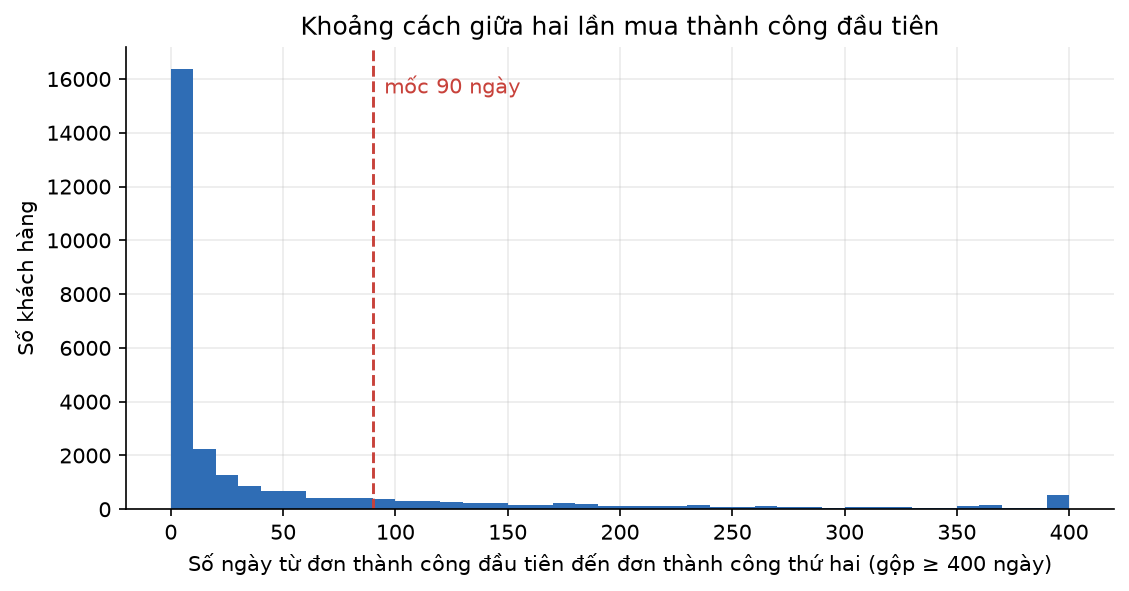

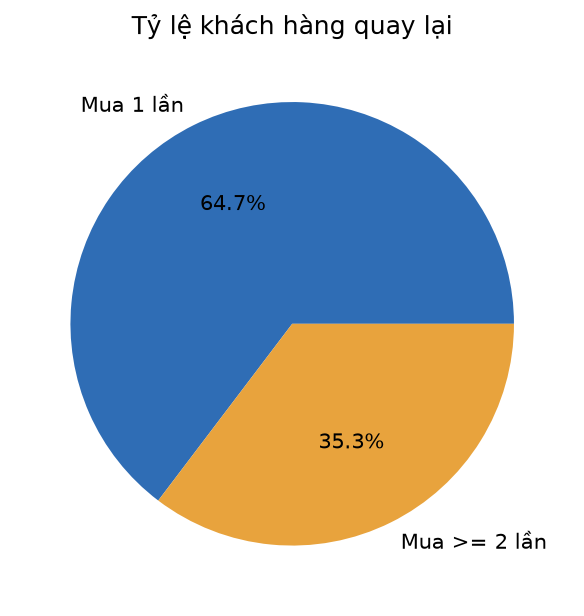

In [37]:
# Chu kỳ mua lại & Lưu Stats
import json

orders = succ.groupby(["Customer ID", "increment_id"]).agg(
    date=("created_at", "min"), rev=("line_net_value", "sum")).reset_index()

od = orders.sort_values(["Customer ID", "date"])
od["rank"] = od.groupby("Customer ID").cumcount()
first = od[od["rank"] == 0].set_index("Customer ID").date
second = od[od["rank"] == 1].set_index("Customer ID").date
gap = (second - first.reindex(second.index)).dt.days

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(gap.clip(upper=400), bins=40, color=BLUE)
ax.axvline(90, color=RED, ls="--", lw=1.4)
ax.text(95, ax.get_ylim()[1] * 0.9, "mốc 90 ngày", color=RED)
ax.set_xlabel("Số ngày từ đơn thành công đầu tiên đến đơn thành công thứ hai (gộp ≥ 400 ngày)")
ax.set_ylabel("Số khách hàng")
ax.set_title("Khoảng cách giữa hai lần mua thành công đầu tiên")

fig.savefig(f"{OUT}/eda7_repurchase_gap.png")
plt.show()

# Tính tỷ lệ khách mua 1 lần (Cho biểu đồ tròn)
order_per_customer = cust['n']
one_time_buyers = (order_per_customer == 1).sum()
repeat_buyers = (order_per_customer > 1).sum()

fig2, ax2 = plt.subplots()
ax2.pie([one_time_buyers, repeat_buyers], labels=['Mua 1 lần', 'Mua >= 2 lần'], autopct='%1.1f%%', colors=[BLUE, ORANGE])
ax2.set_title("Tỷ lệ khách hàng quay lại")
fig2.savefig(f"{OUT}/eda8_pie_chart.png")
plt.show()

